# 3. Stability

Having looked at the source of numerical error being:
- the finite-precision representation computers use for real numbers,
- and the property of problems to amplify input errors by their relative condition number,
we now turn our attention to the one thing we do have control over: what algorithm we use to solve a given problem, and how the algorithm itself affects errors.

```{admonition} Additional resource
:class: warning
Corless & Fillion: A graduate introduction to numerical methods, Ch. 1.4
```

## 3.1 Types of error

Stability is entirely the property of the algorithm used to solve a problem. If an algorithm is stable, this loosely means that it gets the right answer, even if it is not exact.

Let's say we have a fixed
- problem, $f: X \to Y$, e.g. $y = \sin x$ or $y$ solves $Ay = b$,
- floating-point repserentation (with a given precision),
- algorithm for $f$, a map $\tilde{f}: X \to Y$, with steps
$$ x \to \circ x \to \tilde{f} (x). $$

Then the relative **forward error** of the computation is 
$$ \frac{|| \tilde{f}(x) - f(x)||}{||f(x)||}. $$
The algorithm is definitely good if this answer is $\mathcal{O}(\mu_M)$ (read: "of the order of").
```{admonition} Aside
Formally, the "big O" notation means that there exists a constant $c$ such that answer is $\leq c\mu_M$ as $\mu_M \to 0$, uniformly over all input data $x \in X$.
```
```{admonition} Question
Is it reasonable to demand this?
```
If the problem, however, is ill-conditioned, this is not a reasonable ask. Even if the algorithm were to give an exact answer, the answer will not have a relative error of $\mathcal{O}(\mu_M)$.

So instead we define and algorithm as **stable** if $\forall x \in X$, 
$$ \frac{||\tilde{f}(x) - f(\tilde{x})||}{||f(\tilde{x})||} = \mathcal{O}(\mu_M) \quad \text{for some }\tilde{x}\text{ such that}\quad \frac{||\tilde{x} - x||}{||x||} = \mathcal{O}(\mu_M).  $$


Meaning that the algorithm gives "nearly the right answer to nearly the right question".

A stronger requirement for an algorithm is to be **backwards stable**, i.e. $\forall x \in X$
$$ \tilde{f}(x) = f(\tilde{x}) \quad \text{for some }\tilde{x}\text { such that}\quad \frac{||\tilde{x} - x||}{||x||} = \mathcal{O}(\mu_M), $$
in words, it is a requirement for the algorithm to give "exactly the right answer to the nearly right question".

The expression "backwards stable" comes from the related concept of **backward error**. Using the above notation, if there is a value $\tilde{x}$ such that $\tilde{f}(x) = f(\tilde{x})$, then the relative backward error is
$$\frac{||\tilde{x} - x||}{||x||}, $$
whereas the absolute backward error is $||\tilde{x} - x||$. 
But why is it called "backward"? The name comes from the fact that this error measures the deviation from the original input/data $x$ that reproduces the result that was found by the algorithm. [Fig. 1.4.1.](https://tobydriscoll.net/fnc-julia/intro/stability.html#fig-backwarderror) from Driscoll and Braun's Fundamentals of Numerical Computation illustrates the relationship between the absolute error $||\tilde{f}(x) - f(x)||$ and the absolute backward error $||\tilde{x} - x||$:
```{image} img/backwarderror.svg
:name: backwarderror-fig
:align: center
```

```{admonition} Question
Is the floating-point subtraction, $\ominus$ backwards stable?
```
- The exact problem is $f(x_1, x_2) = x_1 - x_2$.
- The algorithm is $\tilde{f}(x_1, x_2) = \circ{x_1} \ominus \circ{x_2} = \left[x_1(1+\varepsilon_1) - x_2(1 + \varepsilon_2)\right](1 + \varepsilon_3)$, where $|\varepsilon_i| \leq \mu_M$ for each $i = 1, 2, 3.$
- By renaming, write as $x_1(1 + \varepsilon_4) - x_2(1 + \varepsilon_5)$, where $|\varepsilon_j| \leq 2\mu_M$ for $j = 4, 5$, which is $f(\tilde{x}_1, \tilde{x}_2)$, i.e. exact for some data close to $x_1$, $x_2$. 
The subtraction algorithm is therefore backwards stable.

```{admonition} Question
Can backwards stable algorithms produce large relative errors $\frac{||\tilde{f}(x) - f(x)||}{||f(x)||}$? If so, how?
```
Absolutely! The only way this can happen though, is if $\kappa$ is very large. An important result is that 

```{admonition} Theorem
:class: hint
If a backwards stable algorithm using floating-point representation is used to solve problem $f(x)$ with relative condition number $\kappa(x)$, then the resulting relative error satisfies
$$ \delta := \frac{||\tilde{f}(x) - f(x)||}{||f(x)||} = \mathcal{O}(\kappa(x)\mu_M).$$
```

**Proof:** Backwards stability means that 
$$ \tilde{f}(x) = f(\tilde{x}) $$
for some $\frac{||x - \tilde{x}||}{||x||} = \mathcal{O}(\mu_M)$.
Using this to replace the $\tilde{f}(x)$ with $f(\tilde{x})$ in the relative error and using the definition of $\kappa$ we get  
$$ \delta = \frac{||f(\tilde{x}) - f(x)||}{||f(x)||} \leq \kappa(x)\frac{||x - \tilde{x}||}{||x||} = \kappa(x)\mathcal{O}(\mu_M). $$

Let's revisit the subtraction example to see this in action:

In [1]:
x1 = 3.0000000000006
x2 = 3.0000000000005
 
x1 - x2

9.992007221626409e-14

We see a large relative error (we know the correct answer is $10^{-13}$) in the computed vs. the exact answer, but we have shown that subtraction is backwards stable. The result is entirely due to the large $\kappa$ of the problem. If $x_1$ were only about $8\cdot 10^{-17}$ larger though, which is a small difference relative to the true $x_1$ (a small backward error), the answer produced by the algorithm would be correct. Meaning: it found an exact solution to a nearby problem, the best thing we can hope for when dealing with an ill-conditioned problem. 

```{admonition} Question
Consider the polynomial 
$$ p(x) = (x-2)^9 = x^9 - 18x^8 + 144x^7 - 672x^6 + 2016x^5 - 4032x^4 + 5376x^3 - 4608x^2 + 2304x - 512. $$
If I were to evaluate $p$ at the points $x = 1.920, 1.921, \ldots, 2.080$ via its coefficients, and overlaid evalutations of $p$ at the same nodes via $(x - 2)^9$, what would you expect to see and why?
```

Let's check this:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

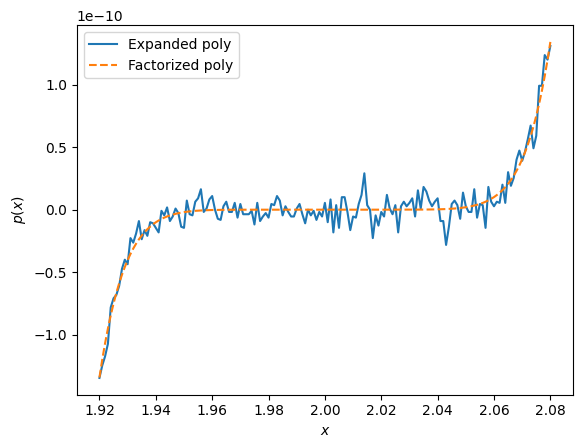

In [3]:
# Expanded poly
p_exp = lambda x: x**9 - 18*x**8 + 144*x**7 - \
                  672*x**6 + 2016*x**5 - 4032*x**4 + \
                  5376*x**3 - 4608*x**2 + 2304*x - 512
# Factorized poly
p_fact = lambda x: (x - 2)**9

x = np.arange(1.920, 2.080, 0.001)
p_exp_arr = p_exp(x)
p_fact_arr = p_fact(x)

plt.figure()
plt.plot(x, p_exp_arr, label = "Expanded poly")
plt.plot(x, p_fact_arr, '--', label = "Factorized poly")
plt.xlabel("$x$")
plt.ylabel("$p(x)$")
plt.legend()
plt.show()

What's going on? We are very close to the roots of the poynomial, so the scale of the $y$-axis is $10^{-10}$, and we observe differences between the two evaluation methods of order $10^{-11}$, with the factorized evaluation giving a visibly smoother curve.

The jitter in the expanded polynomial is due to huge catastrophic cancellation. The coefficients of the polynomial are up to $\approx 10^5$, and they are all input parameters, with respect to which (or wrt $x$) the condition number of $p(x)$ is large (_check this yourself!_). Imagine if you were a computer: you would need to convert all those input data (the coeffs and $x$) to floating-point numbers first, introducing some rounding error, which then gets magnified by the large $\kappa$. 

On the other hand, $(x-2)^9$ only takes in $3$ parameters, and we have seen that neither $x - 2$ (with $x$ close to $2$), nor $x^9$ has a dramatically high condition number (only $\approx 10^2$). The algorithms involved (addition, subtraction) are stable, so error can only creep in through poor conditioning.

```{admonition} Exercises
:class: danger

1. If the relative condition number of the real-valued functions $f$ and $g$ are $\kappa_f$ and $\kappa_g$ respectively, show that for $h(x) = f(g(x))$, 

$$\kappa_h(x) = \kappa_f(g(x))\kappa_g(x).$$


2. The polynomial $p(x) = a_0 + a_1x + \ldots + a_nx^n$ has a root $x = r$. What is the (relative) condition number of the root $r$ with respect to perturbations in the coefficient $a_k$, keeping all other coefficients constant? Simplify your answer as much as possible. Deduce when root finding problems become ill-conditioned (there are multiple cases here!).


3. Consider the machine algorithm (that uses floating-point representation) for subtracting $1$ from a real number. You'll investigate whether it's stable and backwards stable.

    a) The exact problem (a mapping $f: X \mapsto Y$) is $ f(x) = 1 - x. $
Write down in words the steps of the machine algorithm $\tilde{f}$ that computes the difference. Express $\tilde{f}(x)$ in terms of the input $x$.

    b) What does $\tilde{f}(x)$ have to equal, in terms of a floating-point number close to $x$ denoted $\tilde{x},$ for the algorithm to be _backwards stable_?

    c) By expressing $\tilde{x}$ in terms of $x$ and some small relative roundoff error $\varepsilon$ ($|\varepsilon| \leq \mu_M$), eliminate $\tilde{x}$ from the above result. To **first order** in small quantities, what does $\varepsilon$ have to equal for backwards stability? Is this $\varepsilon$ **always** $\mathcal{O}(\mu_M)$ (i.e. for all $x$, uniformly)? What does this mean for the backwards stability of this algorithm?

    d) What is the condition for _stability_ in terms of $f$, $\tilde{f}$, $x$, and $\tilde{x}$? 

    e) Is this algorithm stable? Show your work. 
```